In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

c:\Users\Shen\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Question A

In [5]:
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)
len(train_data), len(test_data)

(8982, 2246)

In [6]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [7]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [8]:
X_train = vectorize_sequences(train_data)
X_test = vectorize_sequences(test_data)
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [9]:
model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

In [10]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
X_val = X_train[:1000]
partial_X_train = X_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [12]:
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/20
16/16 [==============================] - 4s 137ms/step - loss: 2.6588 - accuracy: 0.5426 - val_loss: 1.6965 - val_accuracy: 0.6450
Epoch 2/20
16/16 [==============================] - 1s 53ms/step - loss: 1.3941 - accuracy: 0.7221 - val_loss: 1.2755 - val_accuracy: 0.7250
Epoch 3/20
16/16 [==============================] - 2s 121ms/step - loss: 1.0244 - accuracy: 0.7865 - val_loss: 1.1159 - val_accuracy: 0.7610
Epoch 4/20
16/16 [==============================] - 1s 54ms/step - loss: 0.8073 - accuracy: 0.8290 - val_loss: 1.0317 - val_accuracy: 0.7780
Epoch 5/20
16/16 [==============================] - 1s 60ms/step - loss: 0.6457 - accuracy: 0.8642 - val_loss: 0.9946 - val_accuracy: 0.7780
Epoch 6/20
16/16 [==============================] - 1s 60ms/step - loss: 0.5172 - accuracy: 0.8914 - val_loss: 0.9440 - val_accuracy: 0.8090
Epoch 7/20
16/16 [==============================] - 1s 67ms/step - loss: 0.4177 - accuracy: 0.9122 - val_loss: 0.9297 - val_accuracy: 0.8130
Epoch 8/20


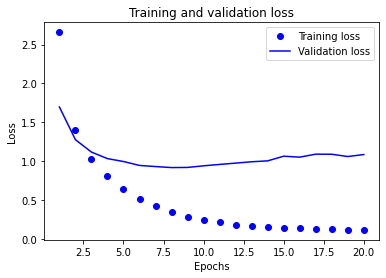

In [13]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

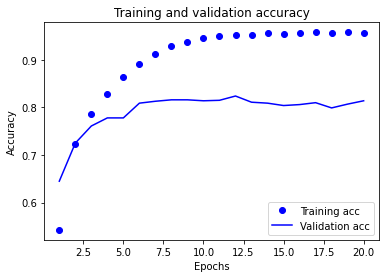

In [14]:
plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Question B

In [ ]:
def build_model(layer_sizes, 
                activation='relu',
                output_classes=46, 
                learning_rate=0.001, 
                loss='categorical_crossentropy'):

    model = keras.Sequential()
    for idx, units in enumerate(layer_sizes):
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(output_classes, activation='softmax'))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=['accuracy'])
    
    return model

In [18]:
def train_model(model, 
                X_train=partial_X_train, 
                y_train=partial_y_train, 
                X_val=X_val,
                y_val=y_val,
                epochs=20, 
                batch_size=32,
                verbose=0):
    
    history = model.fit(X_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),
                        verbose=verbose)
    
    return history

In [19]:
def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.clf()
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

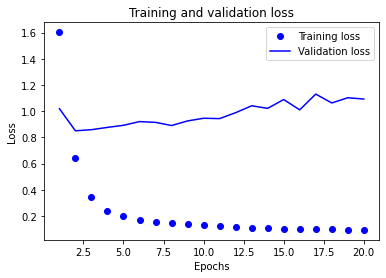

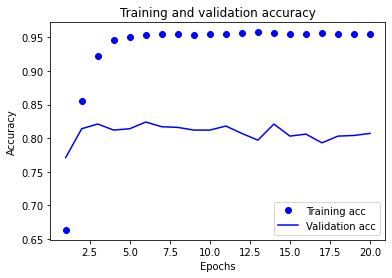

In [22]:
model_A = build_model([64, 64])
history_A = train_model(model_A)
plot_history(history_A)

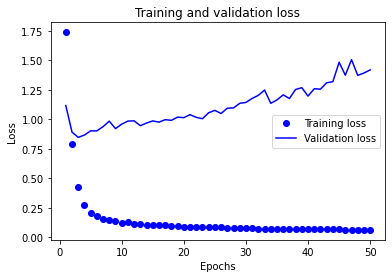

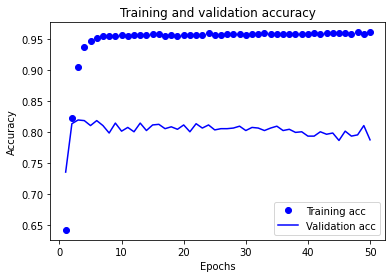

In [23]:
model_B = build_model([64, 128])
history_B = train_model(model_B, epochs=50, batch_size=64)
plot_history(history_B)

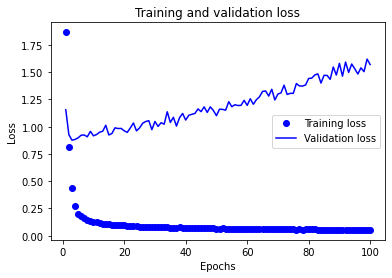

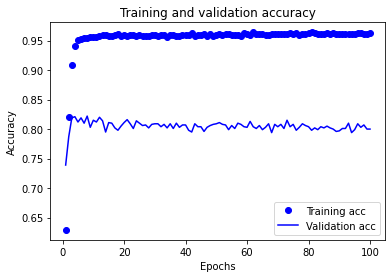

In [24]:
model_C = build_model([128, 128])
history_C = train_model(model_C, epochs=100, batch_size=128)
plot_history(history_C)

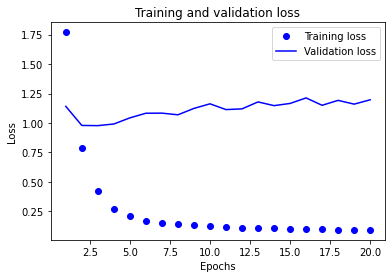

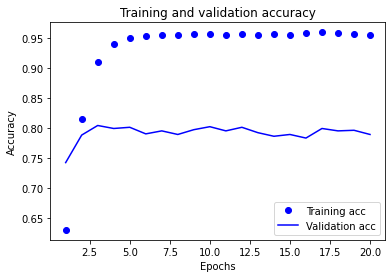

In [27]:
model_D = build_model([128, 64, 32])
history_D = train_model(model_D, batch_size=64)
plot_history(history_D)

In [ ]:
acc = [history_A.history['val_accuracy'][-1],
       history_B.history['val_accuracy'][-1],
       history_C.history['val_accuracy'][-1],
       history_D.history['val_accuracy'][-1]]
print(acc)

[0.8069999814033508, 0.7879999876022339, 0.800000011920929, 0.7889999747276306]


| Model | Model Architecture | Batch-size | Epochs | Learning rate | Validation Accuracy |
|--------|--------------------|------------|--------|--------------|--------------------|
| A | 2 Dense layers (64, 64) | 32 | 20 | 0.001 | 0.807 |
| B | 2 Dense layers (64, 128) | 64 | 50 | 0.001 | 0.788 |
| C | 2 Dense layers (128, 128) | 128 | 100 | 0.001 | 0.800 |
| D | 3 Dense layers (128, 64, 32) | 64 | 20 | 0.001 | 0.789 |

**Model A** has the highest validation accuracy of 0.807.